# Skillbook: распределение секций и рост (§3, §4)

Воспроизводит две секции из `notebooks/skillbook_analysis.ipynb` для трёх **Verified** ранов
со скиллбуками. Стили — publication-quality (IEEE / Nature / Springer): serif-шрифт, тики внутрь,
minor ticks, тонкая серая сетка, PDF + PNG.

- **§3 Распределение секций скиллов** — горизонтальный grouped bar, общие top-8 секций, доля внутри рана (%).
- **§4 Рост скиллбука** — две панели: (a) avg skills per instance по итерациям; (b) суммарное накопленное число скиллов.

Раны подписаны двумя осями: **модель** = ACE-learner (строит скиллбук), **режим обучения** = SWE / Default.

| Label | Model (learner) | Learn | Directory |
|---|---|---|---|
| `Q30 · SWE` | Qwen3-Coder-30B | SWE | `run_20260520_123809_completed_qwen3_4a_swe_verified` |
| `Q30 · Default` | Qwen3-Coder-30B | Default | `run_20260520_144216_completed_qwen3_4a_default_verified` |
| `QNext · Default` | Qwen3-Coder-Next | Default | `run_20260524_160825_completed_qwen3_qwen3next_4a_default_verified` |

> `no_skillbook` (`skip_learn: true`) исключён — нет скиллбуков. У `QNext · Default` агент формально
> Q30, но скиллбук учится QNext-learner'ом; для анализа содержания важна модель learner'а.

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('/root/makharev/agent-swe-ace')
DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'results_figures' / 'skillbook_sections_growth'

# ── Глобальные параметры — IEEE/Nature/Springer, масштаб шрифта ×0.8 (Ctrl- twice) ──
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          7.2,
    'axes.labelsize':     8.0,
    'axes.titlesize':     8.8,
    'xtick.labelsize':    6.4,
    'ytick.labelsize':    6.4,
    'legend.fontsize':    6.4,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#cccccc',
    'axes.linewidth':     0.8,
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth':    1.2,
    'lines.markersize':   4,
    'figure.dpi':         300,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.05,
})

RUNS = {
    'Q30 · SWE':       ('run_20260520_123809_completed_qwen3_4a_swe_verified',     'Q30',   'SWE'),
    'Q30 · Default':   ('run_20260520_144216_completed_qwen3_4a_default_verified', 'Q30',   'Default'),
    'QNext · Default': ('run_20260524_160825_completed_qwen3_qwen3next_4a_default_verified', 'QNext', 'Default'),
}
RUN_ORDER = list(RUNS.keys())
RUN_COLORS = {'Q30 · Default': '#1f77b4', 'Q30 · SWE': '#d62728', 'QNext · Default': '#2ca02c'}
RUN_MARKERS = {'Q30 · Default': 'o', 'Q30 · SWE': 's', 'QNext · Default': '^'}


def save(fig, stem):
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    for fmt in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{stem}.{fmt}', format=fmt)
    print('saved', stem)


def get_benchmark_subdir(run_dir):
    for d in Path(run_dir).iterdir():
        if d.is_dir() and 'SWE-bench' in d.name:
            return d
    return None


def load_skillbooks_per_instance(run_dir):
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir:
        return {}
    sb_dir = bench_dir / 'skillbooks'
    if not sb_dir.exists():
        return {}
    result = {}
    for inst_dir in sorted(sb_dir.iterdir()):
        if not inst_dir.is_dir():
            continue
        result[inst_dir.name] = {}
        for f in sorted(inst_dir.glob('iter_*.json')):
            sb = json.load(open(f))
            result[inst_dir.name][sb['iteration']] = sb
    return result


def extract_all_skills(sb):
    return [{'section': s.get('section', ''), 'content': s.get('content', '')}
            for s in sb.get('skills', {}).values()]

## 3. Распределение секций скиллов

По одной панели на ран: **top-10 секций скиллов этого рана** (сырой count). Оси X независимы
(раны сильно различаются по объёму: Q30/SWE ~13.1k, Q30/Default ~7.6k, QNext/Default ~3.0k),
а общий объём вынесен в заголовок панели. Цвет баров = цвет рана (как в §4).

Q30 · SWE: 13114 skills, 196 distinct sections
Q30 · Default: 7615 skills, 321 distinct sections
QNext · Default: 2979 skills, 348 distinct sections
Q30 · SWE -> [('environment', 2148), ('verification', 1678), ('code_modification', 1086), ('implementation', 1032), ('file_modification', 784), ('fix_strategy', 441), ('fix_implementation', 400), ('debugging', 386), ('bug_fixing', 302), ('execution', 271)]
Q30 · Default -> [('debugging', 606), ('django', 520), ('django_fixes', 406), ('code_modification', 397), ('testing', 221), ('code_fixing', 167), ('symbolic_computation', 163), ('django_development', 147), ('sphinx_autodoc', 147), ('django_orm', 130)]
QNext · Default -> [('code_modification', 287), ('debugging', 191), ('file_modification', 85), ('implementation', 54), ('error_prevention', 53), ('django_development', 53), ('django_orm', 50), ('testing', 43), ('django', 42), ('django_migrations', 40)]


saved skill_sections_per_run


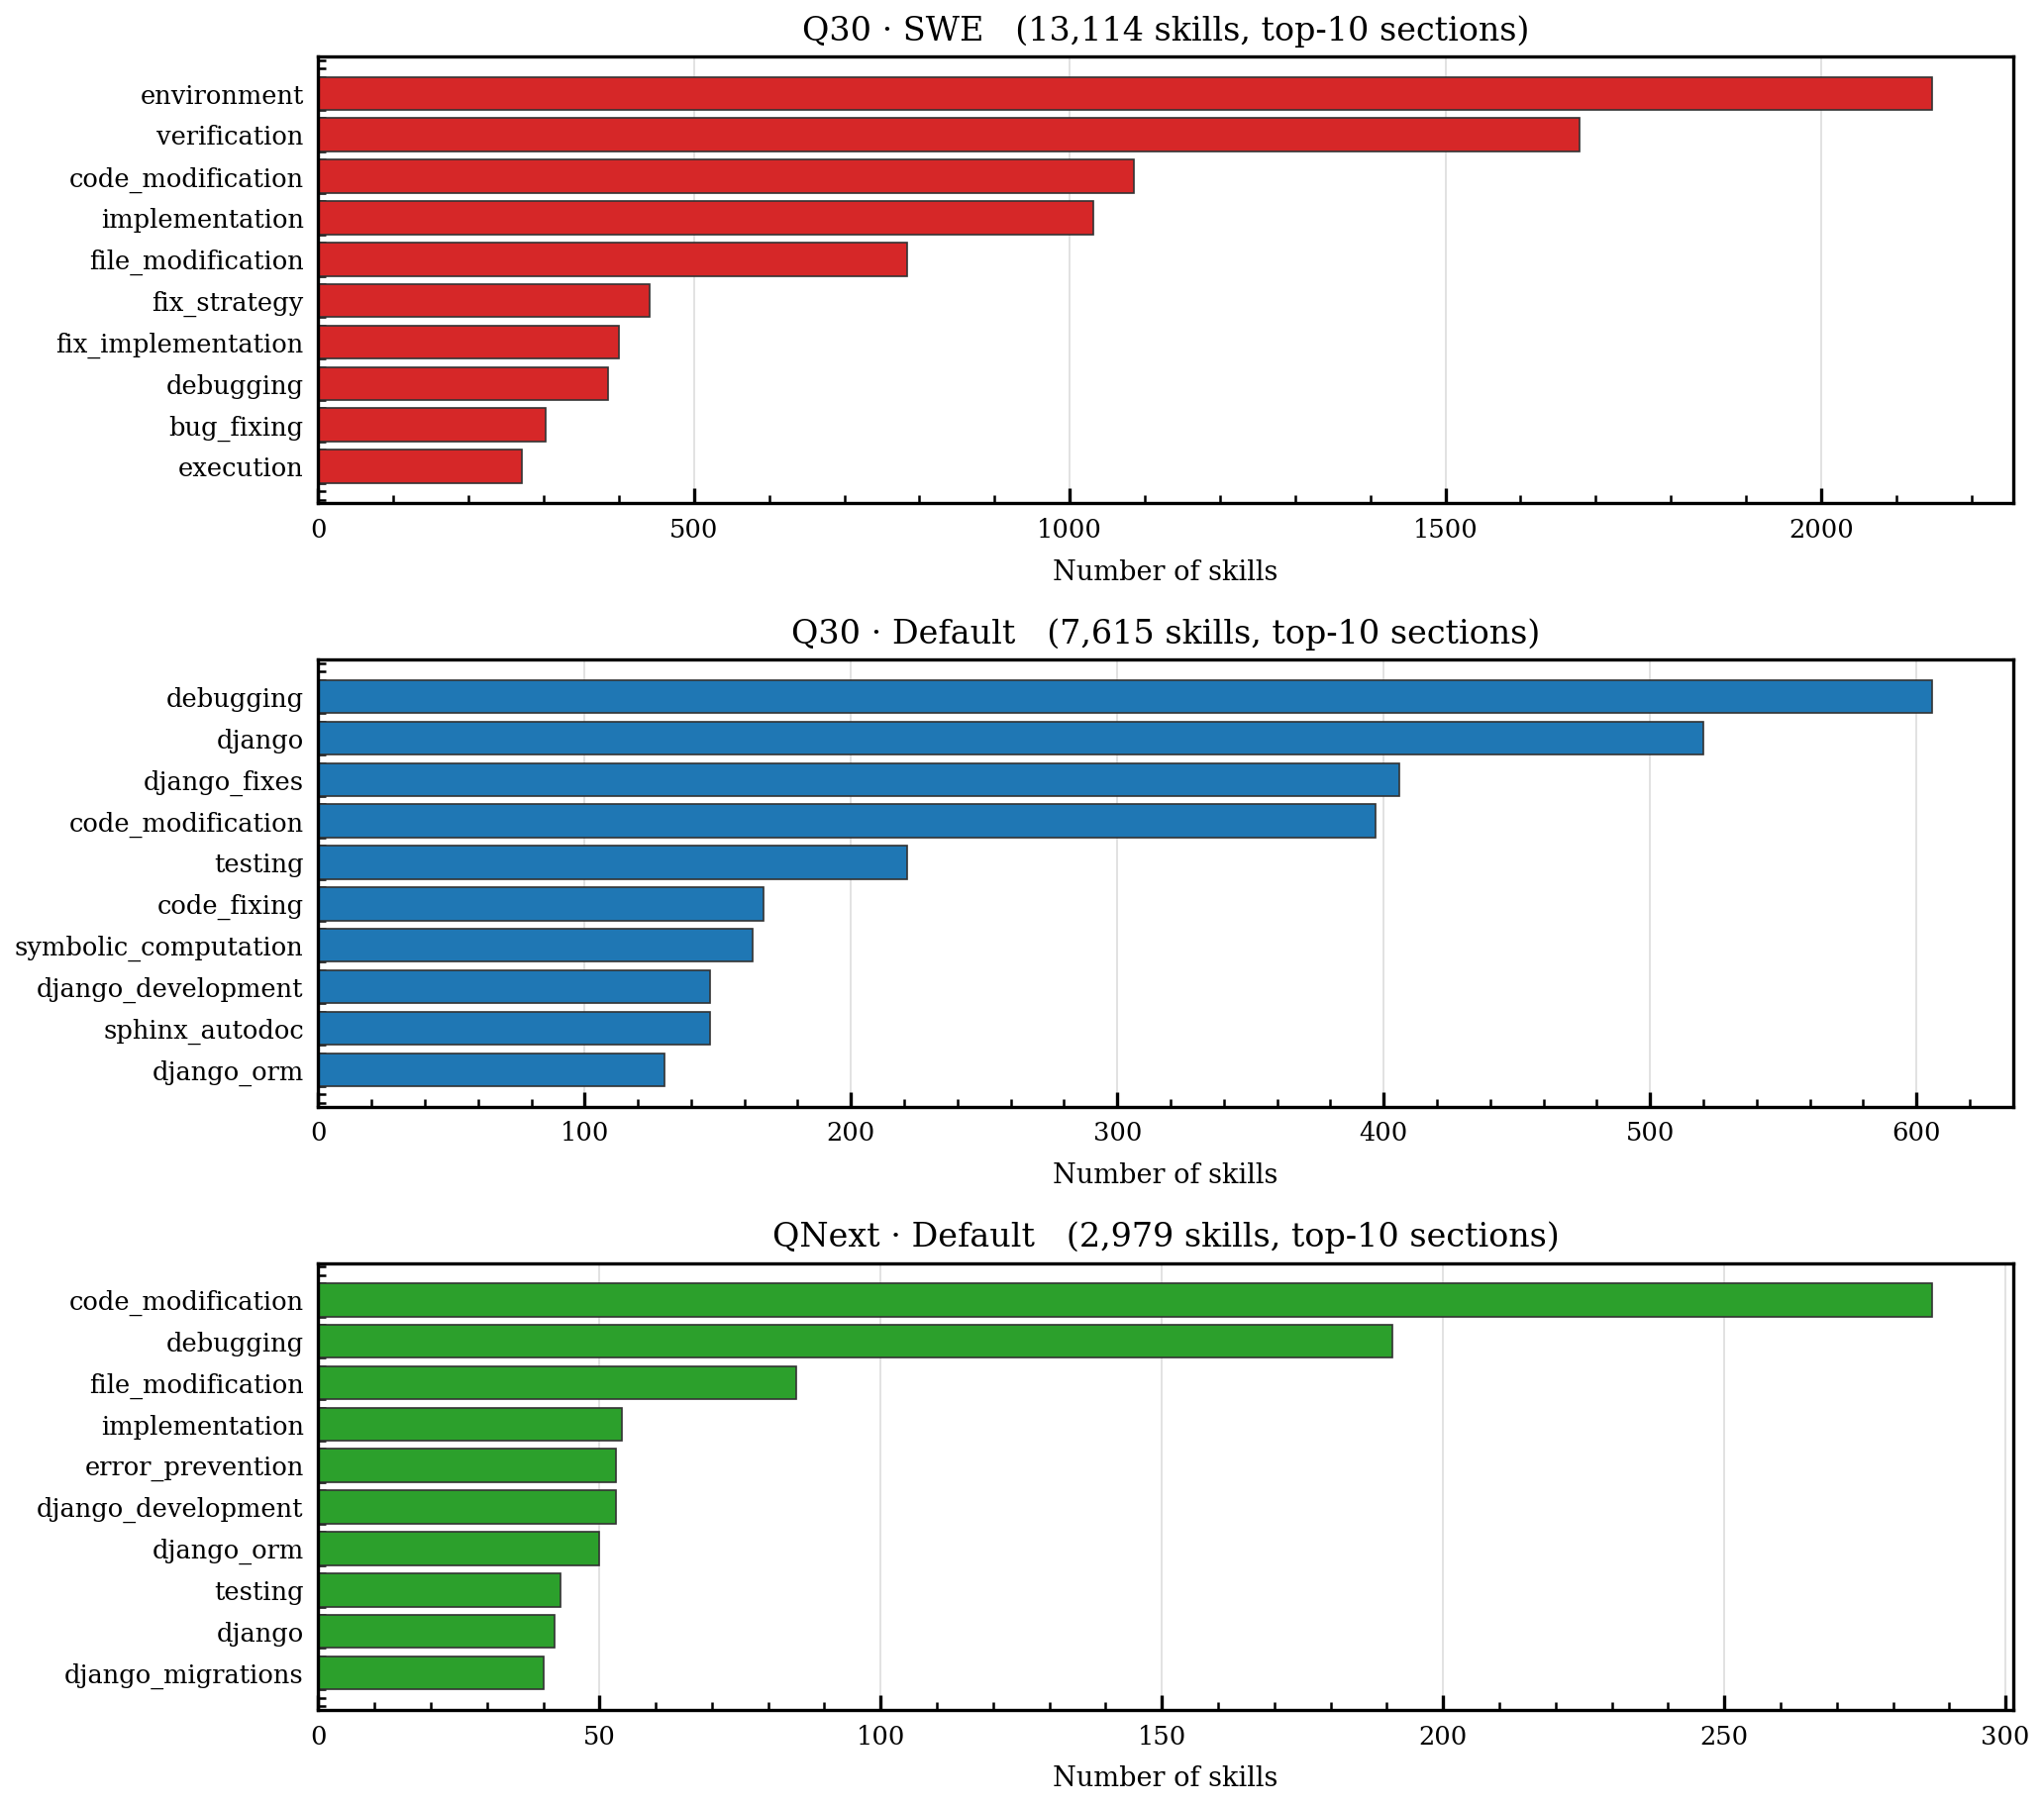

In [2]:
section_counts, totals = {}, {}
for label in RUN_ORDER:
    rd = DATA_DIR / RUNS[label][0]
    all_skills = []
    for inst_sbs in load_skillbooks_per_instance(rd).values():
        for sb in inst_sbs.values():
            all_skills.extend(extract_all_skills(sb))
    section_counts[label] = Counter(s['section'] for s in all_skills)
    totals[label] = len(all_skills)
    print(f'{label}: {totals[label]} skills, {len(section_counts[label])} distinct sections')

# per-run top-10 sections
top10 = {label: section_counts[label].most_common(10) for label in RUN_ORDER}
for label in RUN_ORDER:
    print(label, '->', top10[label])

fig, axes = plt.subplots(3, 1, figsize=(7.0, 6.2))
for ax, label in zip(axes, RUN_ORDER):
    items = top10[label][::-1]                 # ascending → largest on top
    sections = [s for s, _ in items]
    counts = [c for _, c in items]
    ax.barh(sections, counts, color=RUN_COLORS[label], edgecolor='#333333', linewidth=0.4)
    ax.set_xlabel('Number of skills', fontsize=6.5)
    ax.set_title(f'{label}   ({totals[label]:,} skills, top-10 sections)', pad=4, fontsize=8.0)
    ax.tick_params(labelsize=6.2)
    ax.set_axisbelow(True)
    ax.grid(True, axis='x', linewidth=0.4, color='#dddddd', zorder=0)
    ax.minorticks_on()
fig.tight_layout()
save(fig, 'skill_sections_per_run')
plt.show()

**Интерпретация.** Per-run top-10 выявляет структурную разницу между режимами/learner'ами.

- **Q30/SWE** — доминируют «процессные» секции общего назначения (`environment`, `verification`,
  `code_modification`, `implementation`, `file_modification`), мало привязки к конкретному репозиторию.
- **Q30/Default** — топ-секции репо-специфичны (`django`, `django_fixes`, `symbolic_computation`,
  `sphinx_autodoc`, `django_orm`): скиллбук «знает» конкретные библиотеки.
- **QNext/Default** — компактнее и смешаннее: `code_modification`, `debugging`, `django_*`.

По объёму: Q30/SWE ~13.1k, Q30/Default ~7.6k, QNext/Default ~3.0k скиллов.

## 4. Рост скиллбука по итерациям

Per-instance скиллбук растёт по попыткам 1→4.

- **(a) Avg skills per instance** — средний `skill_count` по инстансам, дошедшим до итерации
  (ранние резолвящиеся не имеют iter 3–4). Только среднее.
- **(b) Cumulative skills generated** — суммарное число скиллов, накопленных раном к попытке N
  по всем инстансам; для резолвящихся раньше берём их финальный скиллбук (carry-forward),
  чтобы кривая была монотонной и без двойного счёта.

Q30 · SWE: iters=[1, 2, 3, 4] means=[np.float64(5.7), np.float64(8.2), np.float64(10.4), np.float64(12.3)] (n per iter=[393, 358, 350, 348])
Q30 · SWE: cumulative generated=[2242, 3151, 3890, 4572]
Q30 · Default: iters=[1, 2, 3, 4] means=[np.float64(3.1), np.float64(4.8), np.float64(6.5), np.float64(7.9)] (n per iter=[394, 343, 332, 325])
Q30 · Default: cumulative generated=[1229, 1819, 2362, 2819]
QNext · Default: iters=[1, 2, 3, 4] means=[np.float64(1.5), np.float64(2.1), np.float64(2.4), np.float64(2.8)] (n per iter=[394, 336, 327, 325])
QNext · Default: cumulative generated=[588, 785, 907, 1020]


saved skill_growth


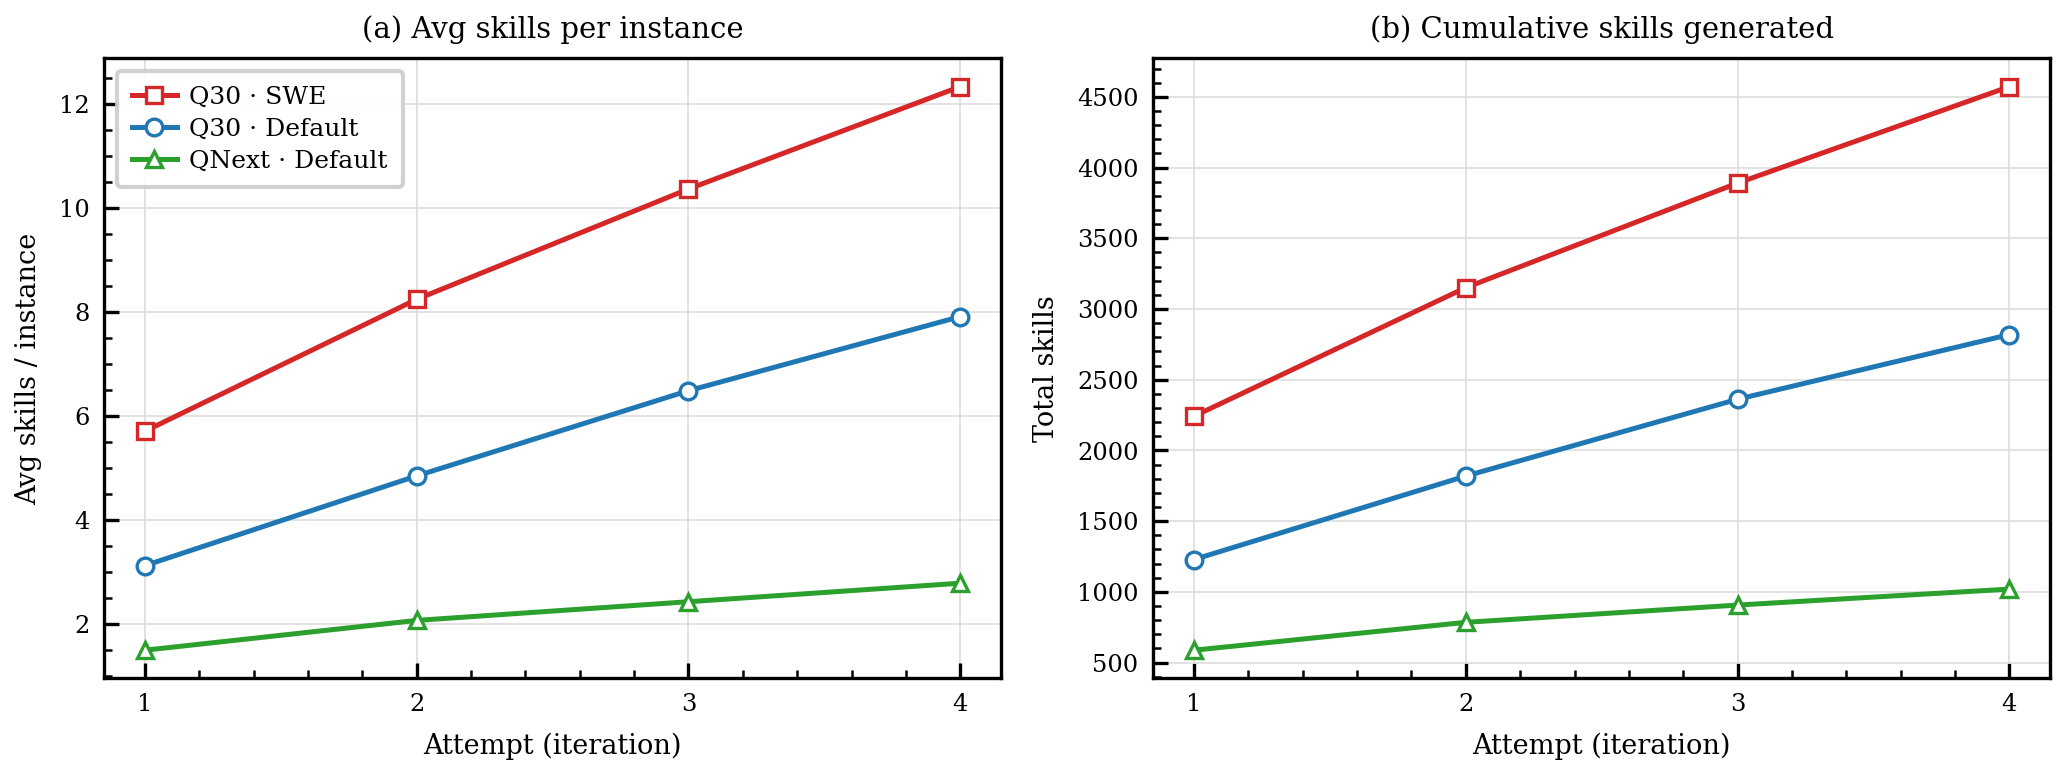

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.7))
for label in RUN_ORDER:
    rd = DATA_DIR / RUNS[label][0]
    sbs = load_skillbooks_per_instance(rd)

    # (a) avg skill_count among instances present at each iteration
    iter_skills = defaultdict(list)
    for inst_id, iters in sbs.items():
        for it, sb in iters.items():
            iter_skills[it].append(sb.get('skill_count', 0))
    iters_sorted = sorted(iter_skills.keys())
    means = [np.mean(iter_skills[i]) for i in iters_sorted]
    print(f'{label}: iters={iters_sorted} means={[round(m, 1) for m in means]} '
          f'(n per iter={[len(iter_skills[i]) for i in iters_sorted]})')
    ax1.plot(iters_sorted, means, color=RUN_COLORS[label], lw=1.2,
             marker=RUN_MARKERS[label], markerfacecolor='white', markeredgewidth=0.8, ms=4,
             zorder=3, label=label)

    # (b) cumulative generated through attempt N (carry-forward final count for resolved instances)
    all_iters = [1, 2, 3, 4]
    cum = []
    for N in all_iters:
        total = 0
        for inst_id, iters in sbs.items():
            known = [it for it in iters if it <= N]
            if known:
                total += iters[max(known)].get('skill_count', 0)
        cum.append(total)
    print(f'{label}: cumulative generated={cum}')
    ax2.plot(all_iters, cum, color=RUN_COLORS[label], lw=1.2,
             marker=RUN_MARKERS[label], markerfacecolor='white', markeredgewidth=0.8, ms=4,
             zorder=3)

# smaller axis-label / title fonts for this short 2-panel figure
for ax, ylabel, title in [(ax1, 'Avg skills / instance', '(a) Avg skills per instance'),
                          (ax2, 'Total skills', '(b) Cumulative skills generated')]:
    ax.set_xlabel('Attempt (iteration)', fontsize=6.5)
    ax.set_ylabel(ylabel, fontsize=6.5)
    ax.set_title(title, pad=5, fontsize=7.0)
    ax.tick_params(labelsize=5.8)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlim(0.85, 4.15)
    ax.set_axisbelow(True)
    ax.grid(True, linewidth=0.4, color='#dddddd', zorder=0)
    ax.minorticks_on()
ax1.legend(loc='upper left', handlelength=1.8, handletextpad=0.5,
           borderpad=0.6, labelspacing=0.35, fontsize=6.0)
fig.tight_layout()
save(fig, 'skill_growth')
plt.show()

**Интерпретация.** Темп накопления (a): Q30/SWE ≈ 5.7→12.3, Q30/Default ≈ 3.1→7.9,
QNext/Default ≈ 1.5→2.8 скиллов/инстанс за 4 попытки. Суммарно (b) Q30/SWE генерирует заметно
больше скиллов, чем Q30/Default, а QNext-learner — меньше всех. SWE копит ~в 1.5–2× быстрее Default
при том же learner'е; QNext-learner даёт более лаконичные скиллбуки.